**Propósito**: construir un inventario verificado de todos los archivos GOES disponibles localmente (qué timestamps existen, qué bandas están presentes en cada uno, y dónde están los gaps). El output es `inventario_goes.parquet`, que alimenta a todas las notebooks siguientes.

## Sección 1 — Inventario de imágenes y caracterización de los instantes faltantes

### 1.1 Inventario de imágenes y bloques faltantes

In [ ]:
# Configuración ----------------------------------------------------------------------------
from pathlib import Path
import pandas as pd
import numpy as np
import re
import shutil

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
CMAP_COBERTURA = (LinearSegmentedColormap
                  .from_list("cobertura", ["#ffffff", "#008e96"])
                  .with_extremes(bad="#929292"))


RUTA_BASE = Path(r"C:\Users\diani\Documents\repositories\nowcasting-bogota")
RUTA_CMIP       = RUTA_BASE / "data" / "cmip_cropped"
RUTA_OUT        = RUTA_BASE / "data_ingestion" / "satellite"
RUTA_OUT.mkdir(parents=True, exist_ok=True)

# Parámetros
CADENCIA_MIN = 10
BANDAS_ESPERADAS = ["CMI_C08", "CMI_C09", "CMI_C10", "CMI_C13", "CMI_C14"]
TRANSICION_G19 = pd.Timestamp("2025-04-04 15:10")  # UTC

def satelite_por_fecha(ts: pd.Timestamp) -> str:
    return "G16" if ts < TRANSICION_G19 else "G19"

In [2]:
# Parser de nombres y escaneo --------------------------------------------------------------
# Formato: CMIPC_20240101-010000.nc
PATTERN = re.compile(
    r"CMIPC_(?P<fecha>\d{8})-(?P<hora>\d{6})\.nc$"
)

def parsear_nombre(filepath: Path) -> dict | None:
    m = PATTERN.search(filepath.name)
    if not m:
        return None
    ts = pd.Timestamp(
        year   = int(m.group("fecha")[:4]),
        month  = int(m.group("fecha")[4:6]),
        day    = int(m.group("fecha")[6:8]),
        hour   = int(m.group("hora")[:2]),
        minute = int(m.group("hora")[2:4]),
        second = int(m.group("hora")[4:6]),
    )
    return {
        "timestamp" : ts,
        "satelite"  : satelite_por_fecha(ts),
        "filepath"  : str(filepath),
        "fuente"    : filepath.parent.name,  # "cmip_cropped" o "faltantes_extraidos"
    }

def escanear_carpeta(ruta: Path) -> pd.DataFrame:
    if not ruta.exists():
        print(f"[AVISO] Carpeta no encontrada: {ruta}")
        return pd.DataFrame()
    registros = []
    for f in ruta.rglob("CMIPC_*.nc"):
        parsed = parsear_nombre(f)
        if parsed:
            registros.append(parsed)
        else:
            print(f"[AVISO] nombre no reconocido: {f.name}")
    df = pd.DataFrame(registros)
    print(f"{ruta.name}: {len(df):,} archivos encontrados")
    return df

df_cmip = escanear_carpeta(RUTA_CMIP)

cmip_cropped: 104,910 archivos encontrados



──────────────────────────────────────────────────
2024
  Rango      : 2024-01-01 00:00:00 → 2024-12-31 23:50:00
  Archivos   : 52,387
  Esperados  : 52,704 (99.4% cubierto)
  Gaps (>10 min): 42
  Gap máximo : 9.2 h
  Top 5 gaps:
          timestamp    gap_h
2024-09-29 02:30:00 9.166667
2024-09-09 06:20:00 5.666667
2024-10-02 16:00:00 5.000000
2024-12-03 10:10:00 4.666667
2024-11-17 15:10:00 3.833333

──────────────────────────────────────────────────
2025
  Rango      : 2025-01-01 00:00:00 → 2025-12-31 23:50:00
  Archivos   : 52,523
  Esperados  : 52,560 (99.9% cubierto)
  Gaps (>10 min): 8
  Gap máximo : 3.5 h
  Top 5 gaps:
          timestamp    gap_h
2025-02-01 20:30:00 3.500000
2025-09-22 18:20:00 2.000000
2025-03-11 16:10:00 0.333333
2025-02-25 17:50:00 0.333333
2025-06-11 03:10:00 0.333333


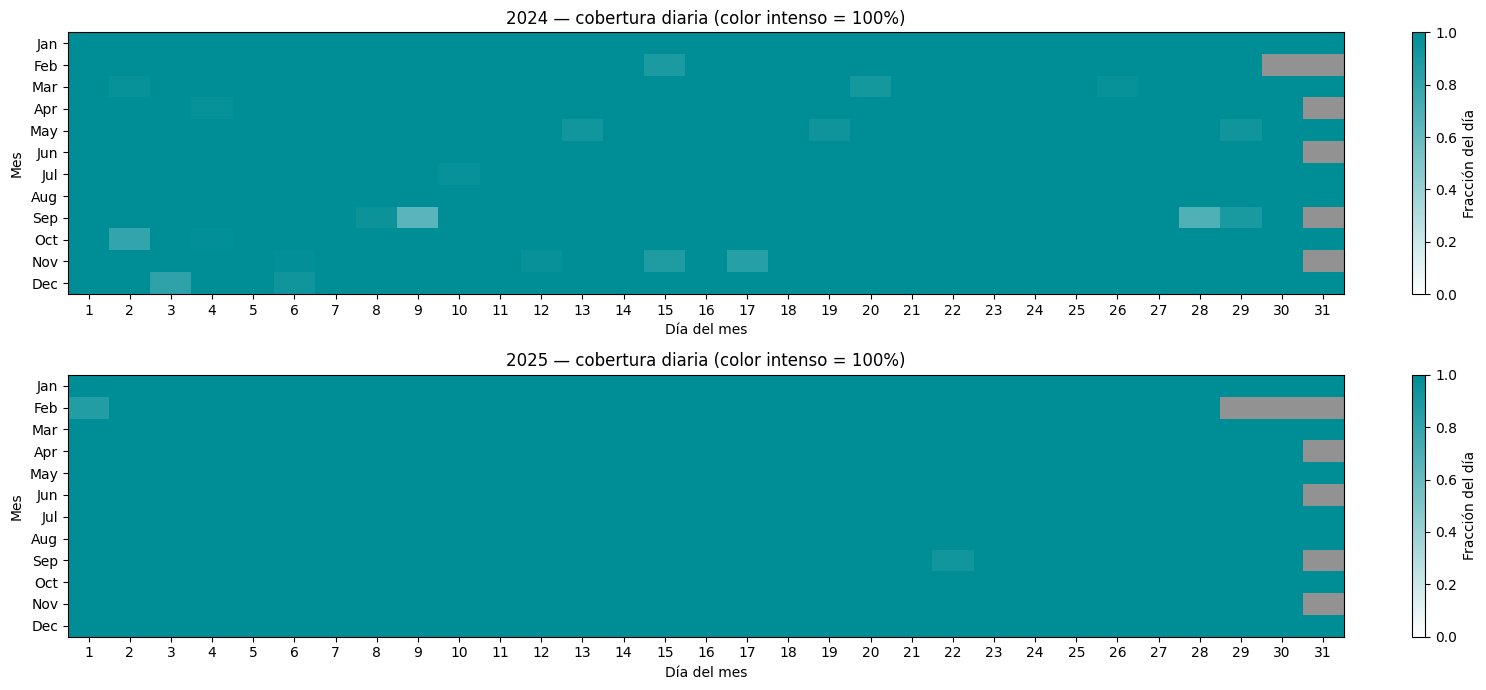

In [9]:
# Cobertura temporal y gaps ----------------------------------------------------------------
# Inventario consolidado: para timestamps duplicados, preferir cmip_cropped
df_unico = (
    df_cmip
    .sort_values(["timestamp", "fuente"])         # cmip_cropped va primero (alfabético)
    .drop_duplicates(subset="timestamp", keep="first")
    .sort_values("timestamp")
    .reset_index(drop=True)
)

fig, axes = plt.subplots(2, 1, figsize=(15, 7))

for ax, año in zip(axes, [2024, 2025]):
    sub = df_unico[df_unico["timestamp"].dt.year == año].copy()
    
    if sub.empty:
        ax.set_title(f"{año} — sin archivos")
        continue

    sub["delta_min"] = sub["timestamp"].diff().dt.total_seconds() / 60
    gaps = sub[sub["delta_min"] > CADENCIA_MIN + 2].copy()
    gaps["gap_h"] = gaps["delta_min"] / 60

    print(f"\n{'─'*50}")
    print(f"{año}")
    print(f"  Rango      : {sub['timestamp'].min()} → {sub['timestamp'].max()}")
    print(f"  Archivos   : {len(sub):,}")
    esperado = len(pd.date_range(f"{año}-01-01", f"{año + 1}-01-01",
                                 freq=f"{CADENCIA_MIN}min", inclusive="left"))
    print(f"  Esperados  : {esperado:,} ({100*len(sub)/esperado:.1f}% cubierto)")
    print(f"  Gaps (>10 min): {len(gaps):,}")
    if not gaps.empty:
        print(f"  Gap máximo : {gaps['gap_h'].max():.1f} h")
        print(f"  Top 5 gaps:")
        print(
            gaps[["timestamp", "gap_h"]]
            .sort_values("gap_h", ascending=False)
            .head(5)
            .to_string(index=False)
        )

    # Heatmap mensual
    dias = pd.date_range(f"{año}-01-01", f"{año}-12-31", freq="D")
    por_dia = sub.groupby(sub["timestamp"].dt.normalize()).size().reindex(dias, fill_value=0)
    tabla = por_dia.groupby([por_dia.index.month, por_dia.index.day]).sum().unstack()  # días inexistentes → NaN
    im = ax.imshow(
        tabla.values / 144,   # fracción del día cubierta
        aspect="auto", vmin=0, vmax=1, cmap=CMAP_COBERTURA, interpolation="none"
    )
    ax.set_title(f"{año} — cobertura diaria (color intenso = 100%)")
    ax.set_xlabel("Día del mes")
    ax.set_xticks(range(tabla.shape[1]))
    ax.set_xticklabels(tabla.columns.tolist())  # columnas son 1-31
    ax.set_ylabel("Mes")
    ax.set_yticks(range(len(tabla.index)))
    ax.set_yticklabels(
        [pd.Timestamp(año, m, 1).strftime("%b") for m in tabla.index]
    )
    plt.colorbar(im, ax=ax, fraction=0.02, label="Fracción del día")

plt.tight_layout()
plt.show()

In [11]:
gaps

,timestamp,satelite,filepath,fuente,delta_min,gap_h
56954,2025-02-01 20:30:00,G16,C:\Users\diani\Documents\repositories\nowcasti...,cmip_cropped,210.0,3.500000
60393,2025-02-25 17:50:00,G16,C:\Users\diani\Documents\repositories\nowcasti...,cmip_cropped,20.0,0.333333
62398,2025-03-11 16:10:00,G16,C:\Users\diani\Documents\repositories\nowcasti...,cmip_cropped,20.0,0.333333
75567,2025-06-11 03:10:00,G19,C:\Users\diani\Documents\repositories\nowcasti...,cmip_cropped,20.0,0.333333
79417,2025-07-07 21:00:00,G19,C:\Users\diani\Documents\repositories\nowcasti...,cmip_cropped,20.0,0.333333
82387,2025-07-28 12:10:00,G19,C:\Users\diani\Documents\repositories\nowcasti...,cmip_cropped,20.0,0.333333
90477,2025-09-22 18:20:00,G19,C:\Users\diani\Documents\repositories\nowcasti...,cmip_cropped,120.0,2.000000
94929,2025-10-23 16:30:00,G19,C:\Users\diani\Documents\repositories\nowcasti...,cmip_cropped,20.0,0.333333


Sobre la grilla regular de diez minutos que define el modo de operación del ABI se identifican los instantes para los cuales no se dispone de una imagen utilizable, ya sea porque el archivo no existe en el registro descargado o porque fue excluido en el control de calidad por defectos presentes en el propio producto CMIP de NOAA. Ambas condiciones se tratan de manera conjunta, dado que para el modelo su efecto es idéntico: la ausencia de la observación en el instante t o en alguno de los instantes que conforman su historia. Los instantes faltantes consecutivos se agrupan en bloques, cuyo inicio, fin, extensión y origen permiten cuantificar su impacto sobre el conjunto etiquetado.

In [ ]:
# Bloques de timestamps faltantes: sin archivo en disco + excluidos en QC ------------------
qc = pd.read_csv(RUTA_OUT / "qc_exclusion_goes.csv", parse_dates=["timestamp"])
excluidos = pd.DatetimeIndex(qc["timestamp"]).tz_convert(None).unique()   # UTC → naive UTC, como el inventario

esperado = pd.date_range("2024-01-01 00:00", "2025-12-31 23:50", freq=f"{CADENCIA_MIN}min")
disponibles = pd.DatetimeIndex(df_unico["timestamp"])
assert disponibles.isin(esperado).all(), "hay timestamps fuera de la grilla de 10 min"
assert excluidos.isin(disponibles).all(), "hay exclusiones de QC que no están en disco"

faltan = pd.DataFrame({"timestamp": esperado.difference(disponibles).union(excluidos)})
faltan["motivo"] = np.where(faltan["timestamp"].isin(excluidos), "excluido_qc", "sin_archivo")
faltan["bloque"] = (faltan["timestamp"].diff() != pd.Timedelta(minutes=CADENCIA_MIN)).cumsum()

gaps_goes = (faltan.groupby("bloque")
             .agg(inicio=("timestamp", "min"), fin=("timestamp", "max"),
                  n_ts=("timestamp", "size"),
                  motivo=("motivo", lambda s: "+".join(sorted(set(s)))))
             .reset_index(drop=True))
gaps_goes["satelite"] = gaps_goes["inicio"].map(satelite_por_fecha)

print(faltan.groupby([faltan["timestamp"].dt.year, "motivo"]).size().unstack(fill_value=0))
print(f"\n{len(gaps_goes)} bloques faltantes")
display(gaps_goes.sort_values("n_ts", ascending=False).head(15))

motivo     excluido_qc  sin_archivo
timestamp                          
2024               166          317
2025                81           37

172 bloques faltantes


,inicio,fin,n_ts,motivo,satelite
64,2024-09-28 15:00:00,2024-09-29 02:20:00,69,excluido_qc+sin_archivo,G16
60,2024-09-08 21:10:00,2024-09-09 06:10:00,55,excluido_qc+sin_archivo,G16
67,2024-10-02 11:00:00,2024-10-02 15:50:00,30,excluido_qc+sin_archivo,G16
61,2024-09-09 15:30:00,2024-09-09 19:50:00,27,excluido_qc+sin_archivo,G16
88,2024-12-03 05:40:00,2024-12-03 10:00:00,27,sin_archivo,G16
86,2024-11-17 11:20:00,2024-11-17 15:00:00,23,excluido_qc+sin_archivo,G16
25,2024-03-20 15:30:00,2024-03-20 19:00:00,22,excluido_qc+sin_archivo,G16
101,2025-02-01 17:10:00,2025-02-01 20:20:00,20,sin_archivo,G16
11,2024-01-22 17:30:00,2024-01-22 20:40:00,20,excluido_qc+sin_archivo,G16
85,2024-11-15 17:20:00,2024-11-15 20:20:00,19,excluido_qc+sin_archivo,G16


De los 105,264 instantes que conforman la grilla de diez minutos entre el 1 de enero de 2024 y el 31 de diciembre de 2025, 601 (166+81+317+37) carecen de una imagen utilizable (0.57%), de los cuales 354 corresponden a archivos inexistentes en el registro y 247 a archivos excluidos en el control de calidad. La pérdida se concentra en 2024, con 483 instantes (0.92% del año), frente a 118 en 2025 (0.22%), y se organiza en 172 bloques de instantes consecutivos cuya extensión va desde un único instante hasta varias horas continuas.

Ambas condiciones presentan, sin embargo, patrones distintos. La mayor parte de los bloques (132 de 172) está formada exclusivamente por archivos excluidos y, salvo uno, se extiende por menos de una hora, lo que corresponde a defectos puntuales en escaneos aislados. Los bloques de mayor extensión responden, en cambio, a una lógica diferente: de los 18 que alcanzan al menos una hora, 11 combinan archivos defectuosos con instantes sin archivo, lo que sugiere que las interrupciones prolongadas en la generación del producto por parte de NOAA vienen acompañadas de escaneos degradados en sus bordes. El caso más extenso lo ilustra con claridad: entre las 15:00 UTC del 28 de septiembre de 2024 y las 02:20 UTC del día siguiente (10:00 a 21:20 en hora local) se suceden 69 instantes sin imagen utilizable. Durante las primeras dos horas y media, archivos defectuosos se alternan con instantes sin archivo, en un patrón de falla intermitente que desemboca, a partir de las 17:30 UTC, en la ausencia continua del producto durante casi nueve horas. En conjunto, el bloque cubre la tarde completa en que se concentra la convección sobre la Sabana.

In [16]:
display(faltan[faltan["timestamp"].between("2024-09-28 14:50", "2024-09-28 17:40")])

,timestamp,motivo,bloque
264,2024-09-28 15:00:00,excluido_qc,65
265,2024-09-28 15:10:00,excluido_qc,65
266,2024-09-28 15:20:00,sin_archivo,65
267,2024-09-28 15:30:00,sin_archivo,65
268,2024-09-28 15:40:00,excluido_qc,65
269,2024-09-28 15:50:00,sin_archivo,65
270,2024-09-28 16:00:00,sin_archivo,65
271,2024-09-28 16:10:00,sin_archivo,65
272,2024-09-28 16:20:00,excluido_qc,65
273,2024-09-28 16:30:00,excluido_qc,65


In [17]:
print(gaps_goes["motivo"].value_counts())
print(gaps_goes[gaps_goes["n_ts"] >= 6]["motivo"].value_counts())   # bloques de al menos una hora

motivo
excluido_qc                132
sin_archivo                 27
excluido_qc+sin_archivo     13
Name: count, dtype: int64
motivo
excluido_qc+sin_archivo    11
sin_archivo                 6
excluido_qc                 1
Name: count, dtype: int64


Esta contigüidad tiene dos implicaciones para el tratamiento de los faltantes. **_En primer lugar, el impacto sobre el conjunto etiquetado debe cuantificarse por bloque y no por origen del faltante_**, dado que ambas condiciones afectan a los mismos episodios de precipitación; esa cuantificación se realiza en la construcción del dataset, donde se cruzan los bloques con las etiquetas y se considera además la historia de imágenes que requiere cada par. **_En segundo lugar, cualquier intento de reconstruir estos instantes a partir de un producto alternativo, como la radiancia del nivel L1b, no puede apoyarse únicamente en la existencia del archivo_**, sino que debe verificar su calidad, puesto que los escaneos que degradaron el producto CMIP pueden haber afectado también a su insumo.

In [ ]:
# Inventario del registro CMIP -----------------------------------------------
inventario = df_unico[["timestamp", "satelite", "filepath"]].copy()
inventario["excluido_qc"] = inventario["timestamp"].isin(excluidos)
inventario = inventario.sort_values("timestamp").reset_index(drop=True)

print(f"Registro CMIP: {len(inventario):,} timestamps  (excluidos en QC: {inventario['excluido_qc'].sum():,})")
print(pd.crosstab(inventario["timestamp"].dt.year, inventario["satelite"], margins=True, margins_name="Total"))


Inventario final exportado: C:\Users\diani\Documents\repositories\nowcasting-bogota\data_ingestion\satellite\inventario_goes.parquet
Total timestamps: 104,910  (excluidos en QC: 247)
satelite     G16    G19   Total
timestamp                      
2024       52387      0   52387
2025       13461  39062   52523
Total      65848  39062  104910


In [20]:
inventario

,timestamp,satelite,filepath,excluido_qc
0,2024-01-01 00:00:00,G16,C:\Users\diani\Documents\repositories\nowcasti...,False
1,2024-01-01 00:10:00,G16,C:\Users\diani\Documents\repositories\nowcasti...,False
2,2024-01-01 00:20:00,G16,C:\Users\diani\Documents\repositories\nowcasti...,False
3,2024-01-01 00:30:00,G16,C:\Users\diani\Documents\repositories\nowcasti...,False
4,2024-01-01 00:40:00,G16,C:\Users\diani\Documents\repositories\nowcasti...,False
...,...,...,...,...
104905,2025-12-31 23:10:00,G19,C:\Users\diani\Documents\repositories\nowcasti...,False
104906,2025-12-31 23:20:00,G19,C:\Users\diani\Documents\repositories\nowcasti...,False
104907,2025-12-31 23:30:00,G19,C:\Users\diani\Documents\repositories\nowcasti...,False
104908,2025-12-31 23:40:00,G19,C:\Users\diani\Documents\repositories\nowcasti...,False


### 1.2 Impacto de los bloques faltantes sobre las etiquetas

In [22]:
# Impacto de los bloques faltantes sobre las etiquetas ---------------------------------------
etiquetas = pd.read_parquet(RUTA_BASE / "data_ingestion" / "ground_truth" / "etiquetas_ground_truth_v2.parquet")
pos = etiquetas[etiquetas["etiqueta"] == 1].copy()
pos["timestamp"] = pos["timestamp"].dt.tz_convert(None)   # UTC sin zona, como el inventario

# Chequeo contra la nb 11: positivos cuyo instante t no tiene archivo (debería dar 583)
print("Positivos en instantes sin archivo :", pos["timestamp"].isin(faltan.loc[faltan["motivo"] == "sin_archivo", "timestamp"]).sum())
print("Positivos en instantes excluidos QC:", pos["timestamp"].isin(faltan.loc[faltan["motivo"] == "excluido_qc", "timestamp"]).sum())

# Positivos afectados por bloque: un par en t se pierde si alguna de t, t-10, ..., t-(L-1)*10 cae en el bloque
t_pos = pos["timestamp"].values
est_pos = pos["codigoestacion"].values
for L in [1, 2, 3, 4]:
    ext = pd.Timedelta(minutes=CADENCIA_MIN * (L - 1))
    gaps_goes[f"pos_L{L}"] = [((t_pos >= i) & (t_pos <= f + ext)).sum()
                              for i, f in zip(gaps_goes["inicio"].values, gaps_goes["fin"].values)]
gaps_goes["estaciones_L4"] = [pd.unique(est_pos[(t_pos >= i) & (t_pos <= f + pd.Timedelta(minutes=30))]).size
                              for i, f in zip(gaps_goes["inicio"].values, gaps_goes["fin"].values)]

ini_local = gaps_goes["inicio"].dt.tz_localize("UTC").dt.tz_convert("America/Bogota")
gaps_goes["split"] = np.select(
    [ini_local < pd.Timestamp("2024-11-15", tz="America/Bogota"),
     ini_local < pd.Timestamp("2025-01-01", tz="America/Bogota")],
    ["train", "val"], "test")

display(gaps_goes.groupby("split")[["n_ts", "pos_L1", "pos_L4"]].sum())
candidatos = gaps_goes[gaps_goes["pos_L4"] > 0].sort_values("pos_L4", ascending=False)
print(f"{len(candidatos)} de {len(gaps_goes)} bloques afectan positivos")
display(candidatos)

Positivos en instantes sin archivo : 583
Positivos en instantes excluidos QC: 193


,n_ts,pos_L1,pos_L4
split,,,
test,118,24,109
train,394,650,828
val,89,102,118


27 de 172 bloques afectan positivos


,inicio,fin,n_ts,motivo,satelite,pos_L1,pos_L2,pos_L3,pos_L4,estaciones_L4,split
64,2024-09-28 15:00:00,2024-09-29 02:20:00,69,excluido_qc+sin_archivo,G16,335,335,335,335,20,train
25,2024-03-20 15:30:00,2024-03-20 19:00:00,22,excluido_qc+sin_archivo,G16,209,224,240,253,18,train
82,2024-11-12 15:50:00,2024-11-12 16:30:00,5,sin_archivo,G16,66,81,96,111,15,train
85,2024-11-15 17:20:00,2024-11-15 20:20:00,19,excluido_qc+sin_archivo,G16,97,97,97,97,8,val
74,2024-10-04 15:50:00,2024-10-04 16:20:00,4,excluido_qc+sin_archivo,G16,8,14,21,30,9,train
164,2025-10-23 22:40:00,2025-10-23 22:40:00,1,excluido_qc,G19,6,13,21,29,8,test
84,2024-11-15 01:00:00,2024-11-15 01:20:00,3,excluido_qc,G16,13,17,21,24,5,train
87,2024-11-22 17:10:00,2024-11-22 17:10:00,1,excluido_qc,G16,5,10,15,21,6,val
165,2025-10-25 18:10:00,2025-10-25 18:10:00,1,excluido_qc,G19,5,10,15,20,5,test
19,2024-02-06 16:50:00,2024-02-06 16:50:00,1,excluido_qc,G16,5,9,14,19,6,train


Para cuantificar el efecto de los instantes faltantes sobre la variable objetivo, los bloques se cruzan con las etiquetas de ventana $(t+1h, t+3h]$ construidas a partir de los registros de IDEAM sobre la misma grilla de diez minutos, cuya construcción no depende de la disponibilidad de imágenes. Un par (estación, $t$) se pierde cuando falta alguna de las imágenes que requiere su entrada. Con una sola imagen ($L = 1$) basta que falte la de $t$; con una historia de $L$ imágenes, basta que falte cualquiera de las comprendidas entre $t - (L-1) \cdot 10$ min y $t$. Por esta razón, un bloque afecta no solo a los pares que contiene, sino también a los que le siguen dentro de la extensión de la historia.

De los 172 bloques, 27 afectan pares con etiqueta positiva. Con $L = 1$ se pierden 776 positivos: 583 en instantes sin archivo y 193 en instantes excluidos por control de calidad. Con $L = 4$ la pérdida asciende a 1,051. Aunque esta cifra representa el 3.7% de los 28,388 positivos del registro completo, su distribución temporal no es homogénea. El 90% corresponde a 2024 (824 positivos en entrenamiento y 118 en validación), lo que equivale a cerca del 10% de los 9,531 positivos con que cuenta ese año para el ajuste y la selección del modelo. La evaluación final, en cambio, pierde 109 positivos de 18,857 (0.6%), todos ellos asociados a exclusiones de un único instante. En estos casos se hace visible el efecto de la historia: un instante aislado que con $L = 1$ afecta a unos pocos positivos llega a afectar a cerca de veinte con $L = 4$.

La pérdida en 2024 se concentra en cuatro tardes convectivas de alcance regional:

Bloque (UTC)|Hora local|Conjunto|Positivos ($L = 4$)|Estaciones
-|-|-|-|-
28-sep-2024 15:00 → 29-sep 02:20|10:00 – 21:20|entrenamiento|335|20
20-mar-2024 15:30 → 19:00|10:30 – 14:00|entrenamiento|253|18
12-nov-2024 15:50 → 16:30|10:50 – 11:30|entrenamiento|111|15
15-nov-2024 17:20 → 20:20|12:20 – 15:20|validación|97|8

En cada una de ellas, entre 8 y 20 de las 63 estaciones registran lluvia fuerte durante la misma tarde, de modo que lo que se pierde no son pares dispersos sino episodios completos del tipo que el modelo necesita aprender a anticipar. El bloque del 12 de noviembre ilustra la magnitud del efecto: con apenas cinco instantes faltantes, cae a media mañana, en la fase previa al desarrollo convectivo, y compromete positivos en 15 estaciones.

La concentración de la pérdida en pocos bloques extensos, situados en el conjunto de entrenamiento y en horas de actividad convectiva, justifica evaluar su recuperación a partir de un producto alternativo. Para ello se verifica a continuación la disponibilidad, en los repositorios de NOAA, de la radiancia de nivel L1b para los instantes afectados, a partir de la cual es posible reconstruir la temperatura de brillo de las bandas infrarrojas.

## Sección 2 — Disponibilidad del producto L1b para la recuperación de instantes faltantes

La disponibilidad se verifica directamente en los repositorios públicos de NOAA, buscando para cada instante $t$ los escaneos de disco completo cuyo inicio cae dentro del intervalo $[t, t + 10\ \text{min})$, en las cinco bandas empleadas por el modelo y en dos productos: el CMIP de nivel L2, del que proviene el registro descargado, y la radiancia calibrada de nivel L1b, a partir de la cual se calcula. Como control positivo se incluyen instantes contiguos al bloque del 28 de septiembre que sí están en el registro y no fueron excluidos, y ambos productos aparecen completos en ellos. Los instantes sin archivo funcionan a su vez como control negativo: en ninguno de los bloques existe el producto CMIP para esos instantes, lo que confirma que su ausencia en el registro se debe a que NOAA no lo generó y no a una falla de la descarga.

In [23]:
# Disponibilidad en NOAA de CMIP y L1b para los bloques con positivos ----------------------
import re
import s3fs

fs = s3fs.S3FileSystem(anon=True)
BUCKET = {"G16": "noaa-goes16", "G19": "noaa-goes19"}
BANDAS_ABI = ["C08", "C09", "C10", "C13", "C14"]
_RE_INICIO = re.compile(r"_s(\d{4})(\d{3})(\d{2})(\d{2})(\d{2})\d_")

def _inicio_escaneo(nombre):
    m = _RE_INICIO.search(nombre)
    if m is None:
        return None
    a, j, H, M, S = map(int, m.groups())
    return pd.Timestamp(a, 1, 1) + pd.Timedelta(days=j - 1, hours=H, minutes=M, seconds=S)

def disponibilidad(timestamps, bucket, producto, bandas=BANDAS_ABI, ventana="10min"):
    """Cuenta archivos por banda cuyo escaneo inicia en [t, t + ventana)."""
    ventana = pd.Timedelta(ventana)
    cache, filas = {}, []
    for t in pd.DatetimeIndex(timestamps):
        h = t.floor("h")
        ruta = f"{bucket}/{producto}/{h:%Y}/{h.dayofyear:03d}/{h:%H}/"
        if ruta not in cache:
            try:
                cache[ruta] = fs.ls(ruta, detail=True)
            except FileNotFoundError:
                cache[ruta] = []
        fila = {"timestamp": t, "producto": producto}
        for b in bandas:
            patron = re.compile(rf"-M\d{b}_")
            sel = [f for f in cache[ruta]
                   if patron.search(f["name"])
                   and (ini := _inicio_escaneo(f["name"])) is not None
                   and t <= ini < t + ventana]
            fila[f"n_{b}"] = len(sel)
            fila[f"mb_{b}"] = round(min(f["size"] for f in sel) / 1e6, 1) if sel else np.nan
        filas.append(fila)
    return pd.DataFrame(filas)

# Controles: instantes en disco, fuera de exclusiones, pegados al bloque del 28-sep
controles = pd.DatetimeIndex(["2024-09-28 14:50", "2024-09-29 02:30"])
assert controles.isin(disponibles).all() and not controles.isin(excluidos).any()

partes = []
for prod in ["ABI-L2-CMIPF", "ABI-L1b-RadF"]:
    partes.append(disponibilidad(controles, "noaa-goes16", prod).assign(bloque="control"))
    for r in candidatos.itertuples():
        ts = pd.date_range(r.inicio, r.fin, freq=f"{CADENCIA_MIN}min")
        partes.append(disponibilidad(ts, BUCKET[r.satelite], prod).assign(bloque=f"{r.inicio:%Y-%m-%d %H:%M}"))
disp = pd.concat(partes, ignore_index=True).merge(faltan[["timestamp", "motivo"]], on="timestamp", how="left")

cols_n = [f"n_{b}" for b in BANDAS_ABI]
disp["completo"] = (disp[cols_n] >= 1).all(axis=1)
assert disp.loc[disp["bloque"] == "control", "completo"].all(), "control positivo falló"

resumen_disp = (disp[disp["bloque"] != "control"]
                .pivot_table(index=["bloque", "motivo"], columns="producto",
                             values="completo", aggfunc=["sum", "size"]))
display(resumen_disp)

sum                      size  \
producto                     ABI-L1b-RadF ABI-L2-CMIPF ABI-L1b-RadF   
bloque           motivo                                               
2024-02-06 15:00 excluido_qc            1            1            1   
2024-02-06 16:50 excluido_qc            1            1            1   
2024-03-20 15:30 excluido_qc           10            1           10   
                 sin_archivo            4            0           12   
2024-09-28 15:00 excluido_qc            9            2            9   
                 sin_archivo           60            0           60   
2024-10-02 17:40 excluido_qc            0            1            1   
2024-10-03 18:50 excluido_qc            1            1            1   
2024-10-03 19:10 excluido_qc            1            1            1   
2024-10-03 19:40 excluido_qc            2            2            2   
2024-10-03 20:20 excluido_qc            1            1            1   
2024-10-04 15:50 excluido_qc            1            2            2   
                 sin_archivo            0            0            2   
2024-10-07 16:30 excluido_qc            1            1            1   
2024-11-12 15:50 sin_archivo            0            0            5   
2024-11-15 01:00 excluido_qc            3            0            3   
2024-11-15 17:20 excluido_qc            0            1            1   
                 sin_archivo            0            0           18   
2024-11-22 17:10 excluido_qc            1            1            1   
2025-01-07 19:30 excluido_qc            1            1            1   
2025-02-28 23:10 excluido_qc            1            1            1   
2025-03-08 03:30 excluido_qc            1            1            1   
2025-03-14 16:40 excluido_qc            1            1            1   
2025-03-14 18:10 excluido_qc            1            1            1   
2025-04-09 17:40 excluido_qc            1            1            1   
2025-04-11 08:00 excluido_qc            1            1            1   
2025-06-13 23:00 excluido_qc            1            1            1   
2025-09-30 10:50 excluido_qc            1            1            1   
2025-10-23 16:20 sin_archivo            0            0            1   
2025-10-23 22:40 excluido_qc            1            1            1   
2025-10-25 18:10 excluido_qc            1            1            1   

                                           
producto                     ABI-L2-CMIPF  
bloque           motivo                    
2024-02-06 15:00 excluido_qc            1  
2024-02-06 16:50 excluido_qc            1  
2024-03-20 15:30 excluido_qc           10  
                 sin_archivo           12  
2024-09-28 15:00 excluido_qc            9  
                 sin_archivo           60  
2024-10-02 17:40 excluido_qc            1  
2024-10-03 18:50 excluido_qc            1  
2024-10-03 19:10 excluido_qc            1  
2024-10-03 19:40 excluido_qc            2  
2024-10-03 20:20 excluido_qc            1  
2024-10-04 15:50 excluido_qc            2  
                 sin_archivo            2  
2024-10-07 16:30 excluido_qc            1  
2024-11-12 15:50 sin_archivo            5  
2024-11-15 01:00 excluido_qc            3  
2024-11-15 17:20 excluido_qc            1  
                 sin_archivo           18  
2024-11-22 17:10 excluido_qc            1  
2025-01-07 19:30 excluido_qc            1  
2025-02-28 23:10 excluido_qc            1  
2025-03-08 03:30 excluido_qc            1  
2025-03-14 16:40 excluido_qc            1  
2025-03-14 18:10 excluido_qc            1  
2025-04-09 17:40 excluido_qc            1  
2025-04-11 08:00 excluido_qc            1  
2025-06-13 23:00 excluido_qc            1  
2025-09-30 10:50 excluido_qc            1  
2025-10-23 16:20 sin_archivo            1  
2025-10-23 22:40 excluido_qc            1  
2025-10-25 18:10 excluido_qc            1

Entre los cuatro bloques que concentran la pérdida de positivos, la disponibilidad de L1b es muy desigual. En el bloque del 28 de septiembre de 2024 el producto L1b está completo en los 69 instantes, tanto en los 60 sin archivo como en los 9 excluidos por control de calidad. En el del 20 de marzo lo está en 14 de los 22 instantes: en los 10 excluidos y en 4 de los 12 sin archivo. En los bloques del 12 y del 15 de noviembre no está disponible en ninguno de los instantes, de modo que su pérdida no admite recuperación y se mantiene como limitación del conjunto de datos.

El comportamiento de los instantes excluidos permite distinguir dos tipos de defecto. En los que forman parte de los bloques extensos, el producto CMIP aparece incompleto en el propio repositorio de NOAA (completo en 2 de los 9 instantes excluidos del 28 de septiembre, en 1 de los 10 del 20 de marzo y en ninguno de los 3 del 15 de noviembre a la madrugada), mientras que la radiancia L1b está disponible. Esto es consistente con defectos originados en la generación del producto de nivel L2, en los que alguna de las bandas no llegó a producirse aunque la observación existe. En las exclusiones de un único instante, en cambio, ambos productos están completos en NOAA, lo que indica que el defecto reside en el contenido de la imagen y no en la ausencia de bandas. Dado que el producto CMIP se deriva de la radiancia L1b, es probable que ese defecto esté presente también en la radiancia, por lo que estos instantes no se consideran candidatos a reconstrucción.

La recuperación es, por tanto, viable con certeza en el bloque del 28 de septiembre, que por sí solo concentra 335 de los 942 positivos que pierde 2024 y corresponde a un episodio registrado en 20 estaciones, y de forma parcial en el del 20 de marzo, donde su utilidad depende de la posición de los instantes que siguen sin cobertura. Puesto que la existencia de un archivo no garantiza su integridad, antes de decidir la reconstrucción se verifica a continuación el tamaño de los archivos L1b del 28 de septiembre frente a los de los instantes de control y la ubicación de los instantes faltantes dentro del bloque del 20 de marzo.

In [24]:
cols_mb = [f"mb_{b}" for b in BANDAS_ABI]
l1b = disp[disp["producto"] == "ABI-L1b-RadF"]

# Tamaños de L1b en el 28-sep frente a los controles (un archivo truncado pesa bastante menos)
display(l1b[l1b["bloque"].isin(["control", "2024-09-28 15:00"])]
        .groupby("bloque")[cols_mb].agg(["min", "median"]).round(1))

# Detalle del 20-mar: qué instantes siguen faltando
display(l1b[l1b["bloque"] == "2024-03-20 15:30"][["timestamp", "motivo", "completo"] + cols_n])

mb_C08        mb_C09        mb_C10        mb_C13         \
                    min median    min median    min median    min median   
bloque                                                                     
2024-09-28 15:00   17.5   17.7   16.6   16.9   20.5   20.7   25.9   26.2   
control            17.4   17.4   16.6   16.6   20.5   20.5   25.9   26.0   

                 mb_C14         
                    min median  
bloque                          
2024-09-28 15:00   25.8   26.1  
control            25.8   26.0

,timestamp,motivo,completo,n_C08,n_C09,n_C10,n_C13,n_C14
217,2024-03-20 15:30:00,excluido_qc,True,2,2,2,2,2
218,2024-03-20 15:40:00,sin_archivo,True,2,2,2,2,2
219,2024-03-20 15:50:00,sin_archivo,True,2,2,2,2,2
220,2024-03-20 16:00:00,excluido_qc,True,2,2,2,2,2
221,2024-03-20 16:10:00,sin_archivo,True,2,2,2,1,1
222,2024-03-20 16:20:00,sin_archivo,False,2,0,2,1,2
223,2024-03-20 16:30:00,sin_archivo,True,1,1,1,1,2
224,2024-03-20 16:40:00,sin_archivo,False,1,1,2,1,0
225,2024-03-20 16:50:00,sin_archivo,False,1,2,0,1,0
226,2024-03-20 17:00:00,sin_archivo,False,1,1,1,1,0


La integridad de los archivos L1b se evalúa comparando su tamaño con el de los instantes de control. En el bloque del 28 de septiembre, el tamaño mínimo por banda coincide con el de los controles y las medianas difieren en menos de 0.3 MB, por lo que no hay indicios de archivos truncados. El bloque es, en consecuencia, reconstruible en su totalidad.

En el bloque del 20 de marzo, la radiancia L1b está completa en los tramos inicial (15:30 a 16:10 UTC, 10:30 a 11:10 en hora local) y final (17:50 a 19:00 UTC, 12:50 a 14:00 en hora local), así como en el instante de las 16:30 UTC. Entre las 16:20 y las 17:40 UTC, en cambio, 8 de los 9 instantes carecen de al menos una de las cinco bandas, de modo que el bloque solo admite una reconstrucción parcial que deja un hueco de hora y media en el centro de la mañana convectiva. En los instantes del tramo inicial se registran además dos escaneos por intervalo de diez minutos en varias de las bandas, lo que exige fijar un criterio de selección en la reconstrucción.

In [25]:
# Positivos recuperables si se reconstruyen los instantes con L1b completo -----------------
bloques_rec = ["2024-09-28 15:00", "2024-03-20 15:30"]
recuperables = pd.DatetimeIndex(disp.loc[(disp["producto"] == "ABI-L1b-RadF") & disp["completo"]
                                         & disp["bloque"].isin(bloques_rec), "timestamp"])
faltan_todos = pd.DatetimeIndex(faltan["timestamp"])
faltan_despues = faltan_todos.difference(recuperables)

t_loc = pos["timestamp"].dt.tz_localize("UTC").dt.tz_convert("America/Bogota")
pos["split"] = np.select([t_loc < pd.Timestamp("2024-11-15", tz="America/Bogota"),
                          t_loc < pd.Timestamp("2025-01-01", tz="America/Bogota")],
                         ["train", "val"], "test")

def perdidos(conjunto, L):
    """Máscara de positivos a los que les falta alguna imagen entre t-(L-1)*10 min y t."""
    m = np.zeros(len(pos), dtype=bool)
    for k in range(L):
        m |= (pos["timestamp"] - pd.Timedelta(minutes=CADENCIA_MIN * k)).isin(conjunto).values
    return m

filas = []
for L in [1, 2, 3, 4]:
    antes, despues = perdidos(faltan_todos, L), perdidos(faltan_despues, L)
    for s in ["train", "val", "test"]:
        en_s = (pos["split"] == s).values
        filas.append({"L": L, "split": s, "perdidos": (antes & en_s).sum(),
                      "recuperados": ((antes & ~despues) & en_s).sum(),
                      "siguen_perdidos": (despues & en_s).sum()})
display(pd.DataFrame(filas).pivot(index="split", columns="L"))

perdidos                recuperados                siguen_perdidos       \
L            1    2    3    4           1    2    3    4               1    2   
split                                                                           
test        24   48   77  109           0    0    0    0              24   48   
train      650  707  767  824         456  455  456  454             194  252   
val        102  107  112  118           0    0    0    0             102  107   

                 
L        3    4  
split            
test    77  109  
train  311  370  
val    112  118

Para estimar el beneficio de la reconstrucción se recalcula la pérdida de positivos suponiendo que se recuperan todos los instantes con radiancia L1b completa en los bloques del 28 de septiembre y del 20 de marzo, y contando cada par una sola vez aunque su historia alcance más de un bloque. La recuperación restituye 456 positivos con $L = 1$ y 454 con $L = 4$, todos en el conjunto de entrenamiento, que reducen su pérdida de 650 a 194 positivos con $L = 1$ y de 824 a 370 con $L = 4$. La cifra recuperada se mantiene prácticamente constante con la longitud de la historia, porque el efecto de arrastre del hueco central del 20 de marzo sobre los pares posteriores se compensa con la recuperación de la historia de los pares que siguen a cada bloque. Los conjuntos de validación y de prueba no se benefician de la reconstrucción, dado que su pérdida proviene de bloques sin radiancia disponible o de exclusiones de un único instante.

Con más de la mitad de la pérdida del conjunto de entrenamiento concentrada en instantes recuperables, se procede a la reconstrucción de la temperatura de brillo a partir de la radiancia L1b. Como paso previo, la reconstrucción se valida en instantes donde ambos productos están disponibles: solo si la temperatura de brillo reconstruida coincide con la del producto CMIP dentro de la precisión con que este se almacena, los instantes reconstruidos se incorporan al registro.

## Sección 3 — Validación de la temperatura de brillo reconstruida a partir de L1b

In [29]:
import importlib
importlib.reload(rl1b)

<module 'reconstruccion_l1b' from 'C:\\Users\\diani\\Documents\\repositories\\nowcasting-bogota\\src\\reconstruccion_l1b.py'>

In [28]:
# Validación de la reconstrucción desde L1b contra CMIP ------------------------------------
import sys
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm import tqdm

sys.path.append(str(RUTA_BASE / "src"))
import reconstruccion_l1b as rl1b

# Muestra: la mañana del 28-sep antes del bloque, más instantes al azar de septiembre de 2024
fijos = pd.to_datetime(["2024-09-28 13:00", "2024-09-28 13:40", "2024-09-28 14:20", "2024-09-28 14:50"])
base = inventario[(inventario["timestamp"].dt.to_period("M") == "2024-09") & ~inventario["excluido_qc"]]
muestra = pd.concat([base[base["timestamp"].isin(fijos)],
                     base[~base["timestamp"].isin(fijos)].sample(16, random_state=42)])
assert len(muestra) == 20, "algún instante fijo no está en disco o está excluido"

filas = []
with ProcessPoolExecutor(max_workers=10) as ex:
    futuros = [ex.submit(rl1b.validar_timestamp, r.timestamp, r.filepath) for r in muestra.itertuples()]
    for f in tqdm(as_completed(futuros), total=len(futuros), desc="Validando L1b"):
        filas.extend(f.result())
val_l1b = pd.DataFrame(filas).sort_values(["timestamp", "banda"])

print(val_l1b["estado"].value_counts())
print(val_l1b.groupby(["estado", "origen_escaneo"], dropna=False).size())
display(val_l1b.groupby("banda").agg(
    n=("estado", "size"),
    geom_ok=("geom_ok", "mean"),
    max_dif_K=("max_dif_K", "max"),
    frac_igual_min=("frac_igual_emp", "min"),
    frac_igual_media=("frac_igual_emp", "mean"),
    frac_dif_1_max=("frac_dif_1", "max"),
    nan_coincide=("nan_coincide", "mean"),
).round(6))

Validando L1b: 100%|██████████| 20/20 [15:11<00:00, 45.57s/it]  


estado
ok    100
Name: count, dtype: int64
estado  origen_escaneo
ok      noaa              100
dtype: int64


,n,geom_ok,max_dif_K,frac_igual_min,frac_igual_media,frac_dif_1_max,nan_coincide
banda,,,,,,,
C08,20,1.0,0.021082,1.0000,1.000000,0.0000,1.0
C09,20,1.0,0.021144,1.0000,1.000000,0.0000,1.0
C10,20,1.0,0.024939,1.0000,1.000000,0.0000,1.0
C13,20,1.0,0.030697,1.0000,1.000000,0.0000,1.0
C14,20,1.0,0.029928,0.9983,0.998906,0.0017,1.0


La reconstrucción se valida sobre 20 instantes de septiembre de 2024 en los que el producto CMIP está disponible en el registro: cuatro de la mañana del 28 de septiembre, previos al bloque por recuperar, y dieciséis elegidos al azar en el resto del mes. Para cada instante y banda, la radiancia L1b se toma del mismo escaneo que dio origen al archivo CMIP. Dado que los archivos del registro no conservan el nombre de su archivo fuente, el escaneo se identifica en el repositorio de NOAA y la comparación se limita a los casos con un único escaneo en la ventana del instante, condición que se cumplió en todos ellos. La radiancia se convierte a temperatura de brillo con la inversa de la función de Planck y los coeficientes que acompañan a cada archivo L1b, y el resultado se compara con el CMIP en el espacio de los enteros con que este se almacena.

La geometría del recorte coincide en todos los casos y el patrón de píxeles sin dato es idéntico en ambos productos. En las bandas C08, C09, C10 y C13 la temperatura de brillo reconstruida es idéntica a la de NOAA en el 100% de los píxeles de los 20 instantes. En la banda C14 la coincidencia va del 99.83% al 100%, y los píxeles restantes difieren en exactamente un nivel de cuantización, atribuible a valores situados en el límite del redondeo. La diferencia máxima antes del empaquetado es de 0.02 a 0.03 K, del orden de la precisión con que se almacena el producto. La reconstrucción reproduce, por tanto, el producto CMIP dentro de su propia precisión de almacenamiento, y los instantes reconstruidos pueden incorporarse al registro sin introducir una fuente de heterogeneidad.

In [30]:
DIR_PRUEBA = RUTA_BASE / "data" / "cmip_l1b_prueba"
DIR_PRUEBA.mkdir(parents=True, exist_ok=True)

fp_ref = inventario.loc[inventario["timestamp"] == pd.Timestamp("2024-09-28 14:50"), "filepath"].iloc[0]
ref = rl1b.referencia_empaquetado(fp_ref)

prueba = muestra[muestra["timestamp"].isin(fijos)]
filas = []
with ProcessPoolExecutor(max_workers=4) as ex:
    futuros = [ex.submit(rl1b.reconstruir_timestamp, r.timestamp, DIR_PRUEBA, ref, Path(fp_ref).name)
               for r in prueba.itertuples()]
    for f in tqdm(as_completed(futuros), total=len(futuros), desc="Reconstruyendo prueba"):
        filas.append(f.result())
rec_prueba = pd.DataFrame(filas)
display(rec_prueba[["timestamp", "estado", "detalle"]])

comp = []
for r in prueba.itertuples():
    comp += [{"timestamp": r.timestamp, **c}
             for c in rl1b.comparar_crudo(r.filepath, DIR_PRUEBA / rl1b.nombre_archivo(r.timestamp))]
display(pd.DataFrame(comp).groupby("banda").agg(
    geom=("geom_igual", "all"), dtype=("dtype_igual", "all"), attrs=("attrs_iguales", "all"),
    frac_igual_min=("frac_igual", "min"), max_dif_crudo=("max_dif_crudo", "max")))

Reconstruyendo prueba: 100%|██████████| 4/4 [02:48<00:00, 42.05s/it] 


,timestamp,estado,detalle
0,2024-09-28 13:40:00,escrito,None
1,2024-09-28 14:50:00,escrito,None
2,2024-09-28 14:20:00,escrito,None
3,2024-09-28 13:00:00,escrito,None


,geom,dtype,attrs,frac_igual_min,max_dif_crudo
banda,,,,,
C08,True,True,True,1.0000,0
C09,True,True,True,1.0000,0
C10,True,True,True,1.0000,0
C13,True,True,True,1.0000,0
C14,True,True,True,0.9983,1


Como prueba de extremo a extremo, los cuatro instantes del 28 de septiembre incluidos en la validación se reconstruyen completos, con el mismo procedimiento que se aplicará a los instantes faltantes, y los archivos resultantes se comparan con los del registro a nivel de los enteros almacenados. Ambos coinciden en la geometría del recorte, el tipo de dato y los atributos de todas las bandas. Los valores son idénticos en las bandas C08 a C13, y en la C14 difieren en un nivel de cuantización en el 0.17% de los píxeles, la misma diferencia observada en la validación, lo que confirma que proviene del cálculo de la temperatura de brillo y no de la escritura de los archivos.

In [33]:
DIR_L1B = RUTA_BASE / "data" / "cmip_l1b"
DIR_L1B.mkdir(parents=True, exist_ok=True)
RUTA_LOG_REC = RUTA_OUT / "log_reconstruccion_l1b.csv"

if RUTA_LOG_REC.exists():
    log_rec = pd.read_csv(RUTA_LOG_REC, parse_dates=["timestamp"])
    print(f"✓ Reconstrucción cargada desde {RUTA_LOG_REC.name}")
else:
    a_reconstruir = recuperables.sort_values()
    print(f"Instantes a reconstruir: {len(a_reconstruir)}")
    filas = []
    with ProcessPoolExecutor(max_workers=6) as ex:
        futuros = [ex.submit(rl1b.reconstruir_timestamp, t, DIR_L1B, ref, Path(fp_ref).name)
                   for t in a_reconstruir]
        for f in tqdm(as_completed(futuros), total=len(futuros), desc="Reconstruyendo"):
            filas.append(f.result())
    log_rec = pd.DataFrame(filas).sort_values("timestamp")
    log_rec.to_csv(RUTA_LOG_REC, index=False)

print(log_rec["estado"].value_counts())
display(log_rec[log_rec["estado"] != "escrito"])

✓ Reconstrucción cargada desde log_reconstruccion_l1b.csv
estado
escrito       82
incompleto     1
Name: count, dtype: int64


,timestamp,estado,detalle,archivo,frac_nan_C08,frac_nan_C09,frac_nan_C10,frac_nan_C13,frac_nan_C14
5,2024-03-20 16:30:00,incompleto,C08 con 16.2% de píxeles sin dato,C:\Users\diani\Documents\repositories\nowcasti...,NaN,NaN,NaN,NaN,NaN


La reconstrucción se aplica a los 83 instantes con radiancia L1b completa de los bloques del 28 de septiembre y del 20 de marzo de 2024. Cada archivo reconstruido se somete a los mismos controles que exige el procedimiento de descarga, es decir, la forma del recorte y una fracción de píxeles sin dato no mayor al 5% por banda, y se escribe con la estructura de los archivos del registro, identificando en sus atributos el producto de origen y los archivos L1b empleados. 

Se reconstruyen 82 instantes. El restante, correspondiente a las 16:30 UTC del 20 de marzo, no supera el control de completitud porque su banda C08 carece de dato en el 16.2% del dominio, lo que indica un escaneo parcial. Dado que este instante se encuentra aislado entre instantes sin cobertura, su exclusión solo afecta a los pares que lo usan como imagen única, y no a los que requieren historia.

In [32]:
recuperados_ok = pd.DatetimeIndex(log_rec.loc[log_rec["estado"] == "escrito", "timestamp"])
faltan_despues = faltan_todos.difference(recuperados_ok)

filas = []
for L in [1, 2, 3, 4]:
    antes, despues = perdidos(faltan_todos, L), perdidos(faltan_despues, L)
    for s in ["train", "val", "test"]:
        en_s = (pos["split"] == s).values
        filas.append({"L": L, "split": s, "perdidos": (antes & en_s).sum(),
                      "recuperados": ((antes & ~despues) & en_s).sum(),
                      "siguen_perdidos": (despues & en_s).sum()})
display(pd.DataFrame(filas).pivot(index="split", columns="L"))

perdidos                recuperados                siguen_perdidos       \
L            1    2    3    4           1    2    3    4               1    2   
split                                                                           
test        24   48   77  109           0    0    0    0              24   48   
train      650  707  767  824         455  455  456  454             195  252   
val        102  107  112  118           0    0    0    0             102  107   

                 
L        3    4  
split            
test    77  109  
train  311  370  
val    112  118

### Validando calidad de los archivos recuperados

In [34]:
import goes_qc

qc_registro = pd.read_parquet(RUTA_OUT / "qc_archivos_goes.parquet")

rec = (log_rec.loc[log_rec["estado"] == "escrito", ["timestamp", "archivo"]]
       .rename(columns={"archivo": "filepath"}))
rec["satelite"] = rec["timestamp"].map(satelite_por_fecha)

# Vecinos del registro (t − 10 y t + 10 min, no excluidos) para medir la continuidad en los bordes
paso = pd.Timedelta(minutes=CADENCIA_MIN)
ts_vecinos = (set(rec["timestamp"] - paso) | set(rec["timestamp"] + paso)) - set(rec["timestamp"])
vecinos = inventario.loc[inventario["timestamp"].isin(ts_vecinos) & ~inventario["excluido_qc"],
                         ["timestamp", "satelite", "filepath"]]
secuencia = pd.concat([rec, vecinos]).sort_values("timestamp").reset_index(drop=True)

stats_rec = goes_qc.estadisticas_archivos(secuencia)
es_nuevo = stats_rec["filepath"].isin(rec["filepath"])

ctrl = goes_qc.controles_internos(stats_rec[es_nuevo], qc_registro)
print(f"Instantes reconstruidos: {len(ctrl)}")
print(f"  completos (cinco bandas, menos del 5% sin dato): {ctrl['completo'].sum()}")
print(f"  con alguna banda duplicada de otro archivo:      {ctrl['duplicado'].sum()}")
print(f"  fuera de rango físico:                           {ctrl['fuera_rango'].sum()}")
print(f"  con la geometría de referencia:                  {ctrl['geometria_ok'].sum()}")
print(f"  superan todos los controles:                     {ctrl['supera_controles'].sum()}")

tabla_cont, trans = goes_qc.continuidad(stats_rec, es_nuevo, qc_registro)
display(tabla_cont.pivot(index="banda", columns="transicion",
                         values=["n", "razon_max", "sobre_umbral"]).round(2))

QC satelital:   0%|          | 0/86 [00:00<?, ?it/s]

Instantes reconstruidos: 82
  completos (cinco bandas, menos del 5% sin dato): 82
  con alguna banda duplicada de otro archivo:      0
  fuera de rango físico:                           0
  con la geometría de referencia:                  82
  superan todos los controles:                     82


n                                       razon_max  \
transicion nuevo → nuevo nuevo → registro registro → nuevo nuevo → nuevo   
banda                                                                      
C08                 79.0              2.0              2.0          0.77   
C09                 79.0              2.0              2.0          0.78   
C10                 79.0              2.0              2.0          0.79   
C13                 79.0              2.0              2.0          0.81   
C14                 79.0              2.0              2.0          0.81   

                                              sobre_umbral                   \
transicion nuevo → registro registro → nuevo nuevo → nuevo nuevo → registro   
banda                                                                         
C08                    0.57             0.39           0.0              0.0   
C09                    0.59             0.41           0.0              0.0   
C10                    0.63             0.58           0.0              0.0   
C13                    0.70             0.45           0.0              0.0   
C14                    0.71             0.68           0.0              0.0   

                             
transicion registro → nuevo  
banda                        
C08                     0.0  
C09                     0.0  
C10                     0.0  
C13                     0.0  
C14                     0.0

Los archivos reconstruidos se someten a los mismos controles internos aplicados al registro en la notebook de control de calidad: completitud, integridad frente al resto del registro, rango físico de la temperatura de brillo y geometría del recorte. Los 82 archivos los superan en su totalidad. Como los tramos reconstruidos quedan insertos entre imágenes del registro original, se evalúa además la continuidad temporal, midiendo el cambio entre imágenes consecutivas como fracción del umbral que delimita el 0.1% de los cambios más intensos del registro. En ninguna banda ni transición se alcanza ese umbral. El valor máximo es de 0.81 entre imágenes reconstruidas consecutivas y de 0.71 en los bordes donde un tramo reconstruido se une al registro original, de modo que la incorporación de estos instantes no introduce discontinuidades en la serie.

## Sección 4 — Inventario final

In [35]:
# ============================================================
# Sección 4 — Inventario final
# ============================================================
inv_cmip = inventario.assign(origen="CMIP")

inv_l1b = ctrl.loc[ctrl["supera_controles"], ["timestamp", "filepath"]].copy()
inv_l1b["timestamp"] = inv_l1b["timestamp"].dt.tz_convert(None)
inv_l1b["satelite"] = inv_l1b["timestamp"].map(satelite_por_fecha)
inv_l1b["excluido_qc"] = False
inv_l1b["origen"] = "L1b"

# Un reconstruido reemplaza al archivo excluido del mismo instante, si lo había
inventario_final = (pd.concat([inv_cmip[~inv_cmip["timestamp"].isin(inv_l1b["timestamp"])], inv_l1b])
                    .sort_values("timestamp").reset_index(drop=True))
assert not inventario_final["timestamp"].duplicated().any()
inventario_final.to_parquet(RUTA_OUT / "inventario_goes.parquet", index=False)

print(f"Inventario final: {len(inventario_final):,} timestamps")
print(inventario_final.groupby(["origen", "excluido_qc"]).size().to_string())
print(pd.crosstab(inventario_final["timestamp"].dt.year, inventario_final["satelite"],
                  margins=True, margins_name="Total"))

# Bloques faltantes residuales
excl_final = pd.DatetimeIndex(inventario_final.loc[inventario_final["excluido_qc"], "timestamp"])
faltan_f = pd.DataFrame({"timestamp": esperado.difference(inventario_final["timestamp"]).union(excl_final)})
faltan_f["motivo"] = np.where(faltan_f["timestamp"].isin(excl_final), "excluido_qc", "sin_archivo")
faltan_f["bloque"] = (faltan_f["timestamp"].diff() != pd.Timedelta(minutes=CADENCIA_MIN)).cumsum()
gaps_final = (faltan_f.groupby("bloque")
              .agg(inicio=("timestamp", "min"), fin=("timestamp", "max"), n_ts=("timestamp", "size"),
                   motivo=("motivo", lambda s: "+".join(sorted(set(s)))))
              .reset_index(drop=True))
gaps_final["satelite"] = gaps_final["inicio"].map(satelite_por_fecha)
gaps_final.to_csv(RUTA_OUT / "gaps_goes.csv", index=False)
print(f"\nInstantes sin imagen utilizable: {len(faltan_f)}  |  bloques: {len(gaps_final)}")
print(faltan_f.groupby([faltan_f["timestamp"].dt.year, "motivo"]).size().unstack(fill_value=0))

# Pérdida residual de positivos, que debe coincidir con 'siguen_perdidos' de la Sección 3
filas = []
for L in [1, 2, 3, 4]:
    m = perdidos(pd.DatetimeIndex(faltan_f["timestamp"]), L)
    for s in ["train", "val", "test"]:
        filas.append({"L": L, "split": s, "perdidos": (m & (pos["split"] == s).values).sum()})
display(pd.DataFrame(filas).pivot(index="split", columns="L", values="perdidos"))

Inventario final: 104,973 timestamps
origen  excluido_qc
CMIP    False          104663
        True              228
L1b     False              82
satelite     G16    G19   Total
timestamp                      
2024       52450      0   52450
2025       13461  39062   52523
Total      65911  39062  104973

Instantes sin imagen utilizable: 519  |  bloques: 171
motivo     excluido_qc  sin_archivo
timestamp                          
2024               147          254
2025                81           37


L,1,2,3,4
split,,,,
test,24,48,77,109
train,195,252,311,370
val,102,107,112,118


In [37]:
inventario.head(2)

,timestamp,satelite,filepath,excluido_qc
0,2024-01-01 00:00:00,G16,C:\Users\diani\Documents\repositories\nowcasti...,False
1,2024-01-01 00:10:00,G16,C:\Users\diani\Documents\repositories\nowcasti...,False


In [40]:
with pd.option_context("display.max_colwidth", None):
    display(inventario_final.groupby(["satelite", "origen", "excluido_qc"]).head(1))

,timestamp,satelite,filepath,excluido_qc,origen
0,2024-01-01 00:00:00,G16,C:\Users\diani\Documents\repositories\nowcasting-bogota\data\cmip_cropped\CMIPC_20240101-000000.nc,False,CMIP
1772,2024-01-13 07:20:00,G16,C:\Users\diani\Documents\repositories\nowcasting-bogota\data\cmip_cropped\CMIPC_20240113-072000.nc,True,CMIP
11447,2024-03-20 15:30:00,G16,C:\Users\diani\Documents\repositories\nowcasting-bogota\data\cmip_l1b\CMIPC_20240320-153000.nc,False,L1b
65911,2025-04-04 15:10:00,G19,C:\Users\diani\Documents\repositories\nowcasting-bogota\data\cmip_cropped\CMIPC_20250404-151000.nc,False,CMIP
66357,2025-04-07 17:30:00,G19,C:\Users\diani\Documents\repositories\nowcasting-bogota\data\cmip_cropped\CMIPC_20250407-173000.nc,True,CMIP


El inventario final integra el registro CMIP con los instantes reconstruidos desde L1b, que reemplazan a los archivos excluidos del mismo instante cuando los hay. Reúne 104,973 instantes: 104,663 archivos CMIP utilizables, 82 reconstruidos (19 que sustituyen archivos excluidos por control de calidad y 63 que cubren instantes sin archivo) y 228 archivos que permanecen excluidos. Cada registro identifica su origen, y los archivos reconstruidos se conservan en una carpeta propia, de modo que el registro descargado se mantiene inalterado y la procedencia de cada imagen es trazable.

Sobre la grilla de diez minutos de los dos años, 519 instantes carecen de una imagen utilizable, el 0.49% del total, agrupados en 171 bloques. La reconstrucción elimina por completo el bloque del 28 de septiembre de 2024 y reduce el del 20 de marzo a su tramo central. En consecuencia, la pérdida de positivos del conjunto de entrenamiento baja de 824 a 370 con una historia de cuatro imágenes, y la de 2024 en su conjunto, de cerca del 10% al 5% de sus positivos. La pérdida residual en validación (118 positivos) y en prueba (109) no admite recuperación desde L1b y se mantiene como limitación del conjunto de datos.